# 📊 Customer Churn Prediction & Risk Segmentation

## 🎯 Objectives:

 Predict whether a customer is likely to churn (leave the service) using historical data.

 Segment customers into risk categories (High, Medium, Low) to prioritize retention strategies.

 ---

## TASK 1: Data Loading & Exploratory Data Analysis

Load the dataset, understand its structure, check for missing values and create relationships between variables.

### 1.1 Load the dataset

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")    # load the dataset

In [52]:
df.shape   # shape of dataset

(7043, 21)

In [53]:
df.info()   # checking column types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [54]:
df.head(10)  # display first 10 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


### 1.2 Identify Target Column & Check Class Imbalance

In [55]:
df['Churn'].value_counts()      # checking target column distribution

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [56]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})      # converting target column to numeric

### 1.3 Check Missing Values

In [57]:
df.isnull().sum()     # checking missing values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 1.4 Summary Statistics

In [58]:
df.describe()     # summary statistics

,SeniorCitizen,tenure,MonthlyCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,0.265370
std,0.368612,24.559481,30.090047,0.441561
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,0.000000
50%,0.000000,29.000000,70.350000,0.000000
75%,0.000000,55.000000,89.850000,1.000000
max,1.000000,72.000000,118.750000,1.000000


### 1.5 Correlation Heatmap

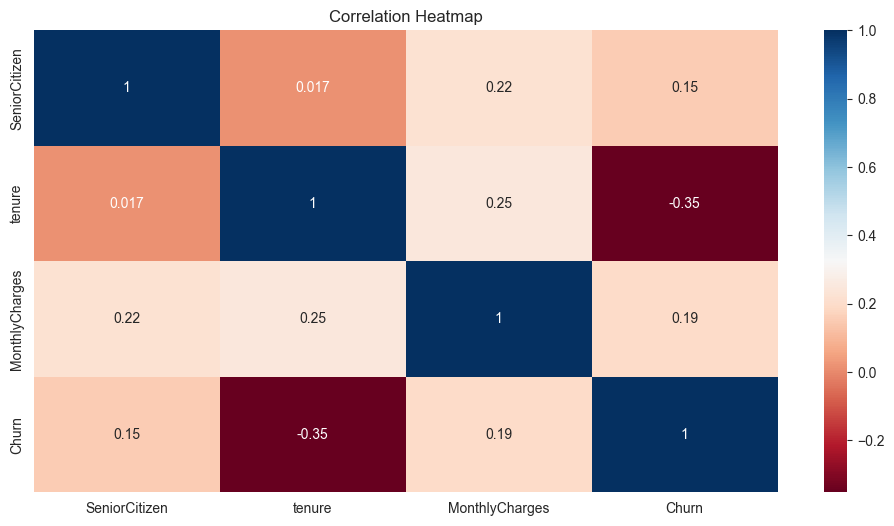

In [59]:
plt.figure(figsize=(12,6))   # set figure size for better readability
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu') # compute correlation matrix and plot heatmap,cmap='RdBu' uses red for positive and blue for negative relationships.
plt.title("Correlation Heatmap") 
plt.show()

### observation: 
The correlation heatmap helps us easily see how different numerical features are related to each other, If two features show a strong correlation, it means they have a strong relationship and could be useful for prediction.

# TASK 2 : Data Preprocessing & Feature Engineering

### 2.1 Fix TotalCharges Data Type

In [60]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')     # convert total charges to numeric, coercing errors to nan

In [61]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)  # Fill NaN with median

C:\Users\arunyadav\AppData\Local\Temp\ipykernel_14776\1171195159.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [62]:
df['TotalCharges'].isnull().sum()    # checking how many values were coerced to nan (missing values)

np.int64(0)

### 2.2 Encode Categorical Variables

In [63]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()   # Create an instance of LabelEncoder

categorical_cols = df.select_dtypes(include='object').columns  # identify categoritical coloumns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])   # Converting each categorical column into numerical form

In [64]:
df.head()  # Display the first few rows to verify changes

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [65]:
df.isnull().sum() 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 2.3 Creating a new useful features

In [66]:
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)    # Feature 1: Charges per month (avoiding division by zero)

In [67]:
df['ChargesPerMonth'].fillna(df['ChargesPerMonth'].median(), inplace=True)  # Fill NaN with median

C:\Users\arunyadav\AppData\Local\Temp\ipykernel_14776\4074178724.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [68]:
df['SeniorWithNoSupport'] = ((df['SeniorCitizen'] == 1) & (df['TechSupport'] == 0)).astype(int)    # Feature 2: Senior citizen without tech support

In [69]:
df['ContractRisk'] = df['Contract'].apply(lambda x: 1 if x == 0 else 0)   # Feature 3: Contract risk : Month-to-month=0, One year=1, Two year=2

In [70]:
df[['ChargesPerMonth', 'SeniorWithNoSupport','ContractRisk']].head()   # checking new features

,ChargesPerMonth,SeniorWithNoSupport,ContractRisk
0,14.925000,0,1
1,53.985714,0,0
2,36.050000,0,1
3,40.016304,0,0
4,50.550000,0,1


### 2.4 Scaling numerical feature

In [71]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']                           # separating features and target

In [72]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)        # scaling numerical features  Scaling ensures all features are on the same scale, which improves model performance.

### 2.5 Spliting data into training and testing sets

In [73]:
from sklearn.model_selection import train_test_split      # splitting data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,        # important for class imbalance
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 23)
Test shape: (1409, 23)


### observation: 
The data is divided into 80% for training the model and 20% for testing its performance and Stratified splitting keeps the proportion of each class (like churn yes/no) balanced in both sets.

# TASK 3 : Model Training & Comparison

### Traning 3 different classification models

1. logistic Regression
2. Random Forest Classifier
3. Gradient Boosting Classifier

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

In [75]:
# initializing models
lr = LogisticRegression(max_iter=1000)            # Logistic Regresssion with increased max iterations to ensure convergence
rf = RandomForestClassifier(random_state=42)      # Random Forest Classifier with a fixed random state for reproducibility
gb = GradientBoostingClassifier(random_state=42)  # Gradient Boosting Classifier with a fixed random state for reproducibility

In [76]:
# training models
lr.fit(X_train, y_train)      # train logistic regression model
rf.fit(X_train, y_train)      # train random forest model
gb.fit(X_train, y_train)      # train gradient boosting model

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


observation on classification models:

1. logistic Regression - Logistic Regression is simple and fast
2. Random Forest Classifier - Random Forest handles non-linear relationships well
3. Gradient Boosting Classifier - Gradient Boosting often gives high accuracy but takes more time

### 3.2 Evaluation each model with Accuracy,Precision, Recall, F-Score and ROC-AUC

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, y_test, y_pred, y_prob):
    print(f"\n{name} Performance:")
    
    print("Accuracy :", accuracy_score(y_test, y_pred))    # accuracy is the ratio of prediction observation to total observation.
    print("Precision:", precision_score(y_test, y_pred))   # precision is the ratio of true positive predictions to the total predicted positives.
    print("Recall   :", recall_score(y_test, y_pred))      # recall is the ratio of true positive predictions to the total actual positives.
    print("F1 Score :", f1_score(y_test, y_pred))          # f1 score is the weighted average of precision and recall, providing a balance between the two metrics.
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))     # roc auc is the curve under the reciver operating characteristic curve, measures the ability of model to distinguish between classes.

In [78]:
lr_pred = lr.predict(X_test) # logistic regression prediction 
rf_pred = rf.predict(X_test) # random forest prediction
gb_pred = gb.predict(X_test) # gradient boosting prediction

# Probabilities (needed for ROC-AUC)
lr_prob = lr.predict_proba(X_test)[:, 1] 
rf_prob = rf.predict_proba(X_test)[:, 1]
gb_prob = gb.predict_proba(X_test)[:, 1]

In [79]:
# Evaluating all models
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)   # evaluating logistic regression model
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)         # evaluating random forest model
evaluate_model("Gradient Boosting", y_test, gb_pred, gb_prob)     # evaluating gradient boosting model


Logistic Regression Performance:
Accuracy : 0.8026969481902059
Precision: 0.6610738255033557
Recall   : 0.5267379679144385
F1 Score : 0.5863095238095238
ROC-AUC  : 0.8455268800537343

Random Forest Performance:
Accuracy : 0.7892122072391767
Precision: 0.627906976744186
Recall   : 0.5053475935828877
F1 Score : 0.56
ROC-AUC  : 0.8276292335115866

Gradient Boosting Performance:
Accuracy : 0.8069552874378992
Precision: 0.6746575342465754
Recall   : 0.5267379679144385
F1 Score : 0.5915915915915916
ROC-AUC  : 0.8448965356893746


### 3.3 ploting Confusion Matrix for each model

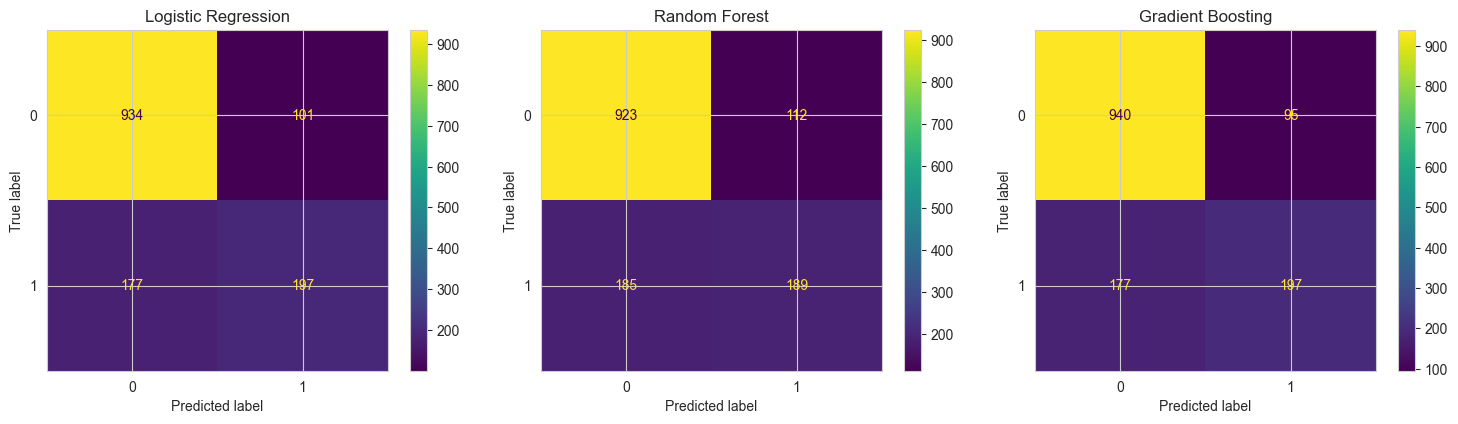

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4)) 

models = [
    ("Logistic Regression", lr_pred),           # model name and predicctions for logistics regression
    ("Random Forest", rf_pred),                 # model name and predictions for random forest
    ("Gradient Boosting", gb_pred)              # model name and predications for gradient boosting
]

for ax, (name, pred) in zip(axes, models):     #
    cm = confusion_matrix(y_test, pred)   # compute confusion matrix for the current model
    disp = ConfusionMatrixDisplay(cm)     # create confusion matrix and display
    disp.plot(ax=ax)                      # plot confusion matrix on the corresponding subplot
    ax.set_title(name)                    # set title for each subplot to the model name

plt.tight_layout()
plt.show()

### 3.4 ploting ROC(Recevier operating characteristic) Curve Comparison on one chart

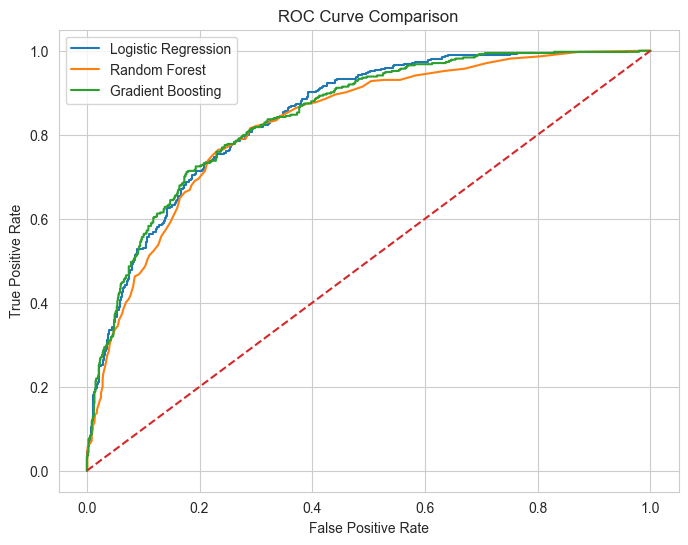

In [81]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)     # compute ROC curve for logistic regression
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)     # compute ROC curve for random forest
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)     # compute ROC curve for gradient boosting

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(gb_fpr, gb_tpr, label="Gradient Boosting")

plt.plot([0,1], [0,1], linestyle='--')  # baseline diagonal line representing random guessing

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### 3.5 Hyperparameter Tuning using GridsearchCV

In [82]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200], # number of trees in a random forest model, more trees can improve performance but also increase training time.
    'max_depth': [5, 10, None], # maximum depth of tree, deeper trees can capture more complex patterns but may overfit the training data.
    'min_samples_split': [2, 5] # minimum number of samples required to split an internal node.
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42), # using random forest for hyperparameter tuning
    param_grid,    # grid of hyper parameters to search
    cv=3,          # 3 different splits of the data quickly evaluate performance acrocess different hyperparameter combinations
    scoring='f1',  # using f1 score for evaluation, which is a good metric for imbalanced for churn prediction
    n_jobs=-1      # using all avaiable cpus for faster computation
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [83]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)              # making predictions with the best model from grid search
best_prob = best_model.predict_proba(X_test)[:, 1]  # getting probabilities for the positive class (churn)

evaluate_model("Best Tuned Model", y_test, best_pred, best_prob)


Best Tuned Model Performance:
Accuracy : 0.7998580553584103
Precision: 0.6597222222222222
Recall   : 0.5080213903743316
F1 Score : 0.5740181268882175
ROC-AUC  : 0.8370017308636233


### observation:
In this task, multiple machine learning classification models were trained and evaluated to predict customer churn. Performance metrics such as Accuracy, Precision, Recall, and ROC-AUC score were used for comparison. The best-performing model showed strong predictive capability in identifying customers likely to churn.

# TASK 4: Customer Risk Segmentation

### 4.1 Using predicted probabilities from the best model

In [84]:
best_model_prob = best_model.predict_proba(X_test)[:, 1]  # gettinng probabilities for the positive class (churn) from the best model

import pandas as pd

risk_df = pd.DataFrame(X_test) # Creating dataframe on X_test

risk_df['ChurnProbability'] = best_model_prob  # Adding churn probability column

### 4.2 Creating 3 Risk Tiers based on churn probabilities

In [85]:
# Function for customers classification based on churn probability
def risk_segment(prob):

    # High Risk
    if prob >= 0.70:
        return 'High Risk'

    # Medium Risk
    elif prob >= 0.40:
        return 'Medium Risk'

    # Low Risk
    else:
        return 'Low Risk'

risk_df['RiskTier'] = risk_df['ChurnProbability'].apply(risk_segment)   # Classifying customers into risk tiers based on their churn probability

In [86]:
print("Customer Risk Segmentation Preview:\n")      # preview of the risk segmentation with churn probability and assigned risk tier
print(risk_df[['ChurnProbability', 'RiskTier']].head()) 

# Risk distribution
print("\nRisk Tier Distribution:\n")   # risk distribution showing how many customers full into each risk tier based on the predicted churn probabilities
print(risk_df['RiskTier'].value_counts())

Customer Risk Segmentation Preview:

   ChurnProbability   RiskTier
0          0.012793   Low Risk
1          0.777206  High Risk
2          0.085877   Low Risk
3          0.336483   Low Risk
4          0.018498   Low Risk

Risk Tier Distribution:

RiskTier
Low Risk       980
Medium Risk    331
High Risk       98
Name: count, dtype: int64


### 4.3 Count customers in each tier

In [87]:
tier_counts = risk_df['RiskTier'].value_counts()   # final count of customers in each risk tier, which can be used for further analysis or visualization

print("Customer Count by Risk Tier:\n")
print(tier_counts)

Customer Count by Risk Tier:

RiskTier
Low Risk       980
Medium Risk    331
High Risk       98
Name: count, dtype: int64


### 4.4 Compute Average MonthlyCharges average Tenure and contract type distribution.

In [88]:
analysis_df = df.loc[risk_df.index].copy()    # creating a new dataframe for analysis using the same indices as risk_df to ensure alignment of data

analysis_df['RiskTier'] = risk_df['RiskTier'] # Adding Risk Tier

#### 4.4.1 Average MonthlyCharges and tenure by Risk Tier

In [89]:
tier_summary = analysis_df.groupby('RiskTier')[['MonthlyCharges', 'tenure']].mean()  # calculating Average MonthlyCharges and tenure by risk tier to understand the chracteristics of customers in each risk tier 

print("\nAverage MonthlyCharges and Tenure:\n")
print(tier_summary)


Average MonthlyCharges and Tenure:

             MonthlyCharges     tenure
RiskTier                              
High Risk         64.351531  29.112245
Low Risk          66.280000  32.219388
Medium Risk       65.694562  32.314199


#### 4.4.2 Contract Type Distribution

In [90]:
contract_distribution = pd.crosstab(  # cross tabulation to analyze the distribution of contract types across different risk tiers
    analysis_df['RiskTier'],   
    analysis_df['Contract'],
    normalize='index'
) * 100

print("\nContract Type Distribution (%):\n")
print(contract_distribution)


Contract Type Distribution (%):

Contract             0          1          2
RiskTier                                    
High Risk    60.204082  22.448980  17.346939
Low Risk     56.020408  19.489796  24.489796
Medium Risk  49.848943  24.169184  25.981873


### 4.5 comparing the three risk tiers using a grouped bar chart

#### 4.5.1 Grouped Bar Chart for MonthlyCharges and Tenure

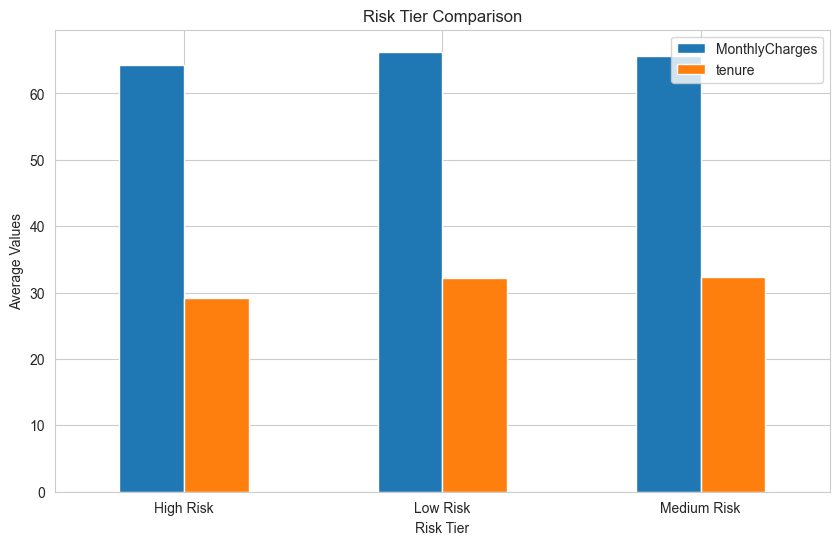

In [91]:
tier_summary.plot(    # visualizing the average monthly charges and tenure by risk tier using a bar plot
    kind='bar',
    figsize=(10, 6)
)

plt.title("Risk Tier Comparison")  
plt.xlabel("Risk Tier")   
plt.ylabel("Average Values")
plt.xticks(rotation=0)
plt.show()

#### 4.5.2 Grouped Bar Chart for Contract Distribution

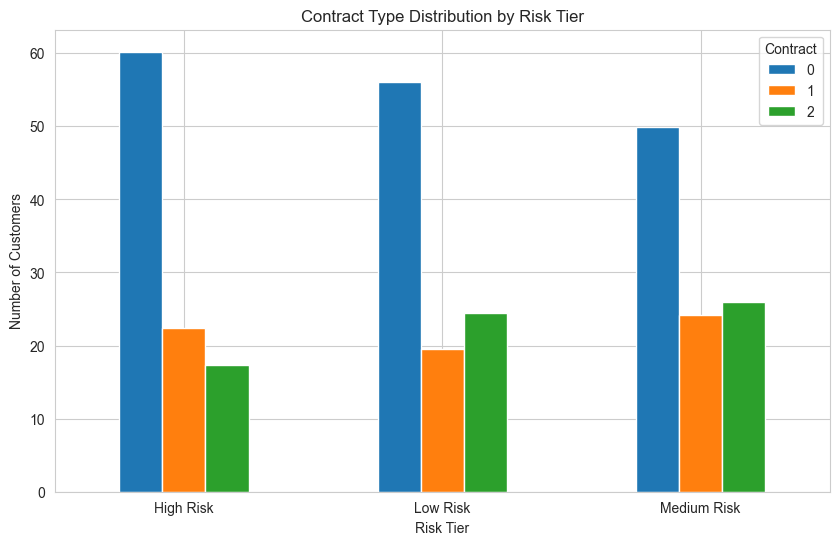

In [92]:
contract_distribution.plot(   # visualizing the distribution of contract types across risk tiers using a bar plot
    kind='bar',
    figsize=(10, 6)
)

plt.title("Contract Type Distribution by Risk Tier")
plt.xlabel("Risk Tier")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

### observation:
Customers were segmented into High, Medium, and Low Risk categories based on churn probability scores predicted by the model. High-risk customers were found to have shorter tenure and higher monthly charges, while low-risk customers generally had stable and long-term service usage. This segmentation can help businesses focus retention efforts more effectively.

#  TASK 5: VISUALIZATIONS

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")    # styling seaborn plots with a white grid background for better readability

### 5.1 Feature Importance bar chart (Top 10 Features) CHART-1

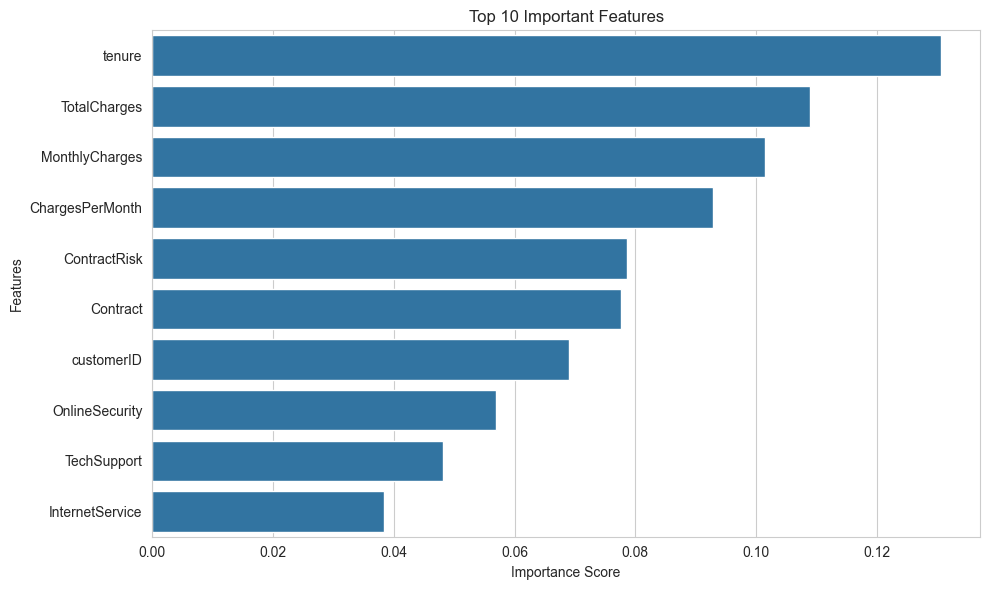

In [94]:
# Using original dataframe column names for feature importance visualization

feature_importance = pd.DataFrame({           # creating a dataframe to hold feature names and their corresponding importance scores from the best model
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(   # sorting the features by their importance scores in descending order to identify the most influential features for churn prediction
    by='Importance',
    ascending=False
)

top_features = feature_importance.head(10)  # selecting the top 10 most important features for visualization

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

### 5.2 Churn Rate by Contract Type CHART-2

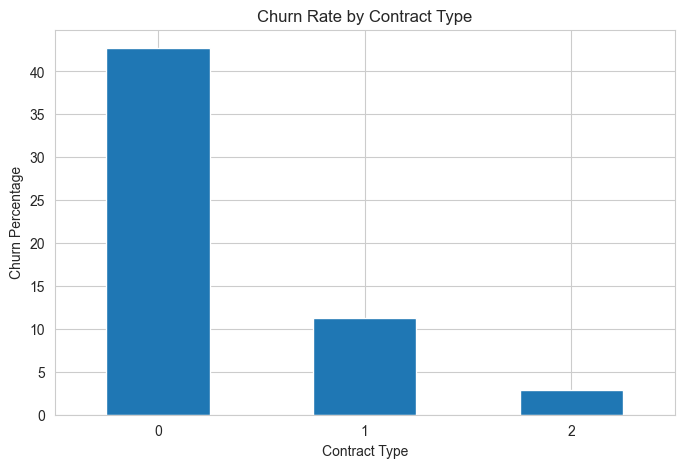

In [95]:
contract_churn = pd.crosstab(  # calculating the chrurn rate for each contract type by creating a cross tabulation of contract types and chrurn status and normalizing it to get percentages
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn[1].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Percentage")
plt.xticks(rotation=0)
plt.show()

### 5.3 Churned vs Not Churned Customers tenure distribution CHART-3

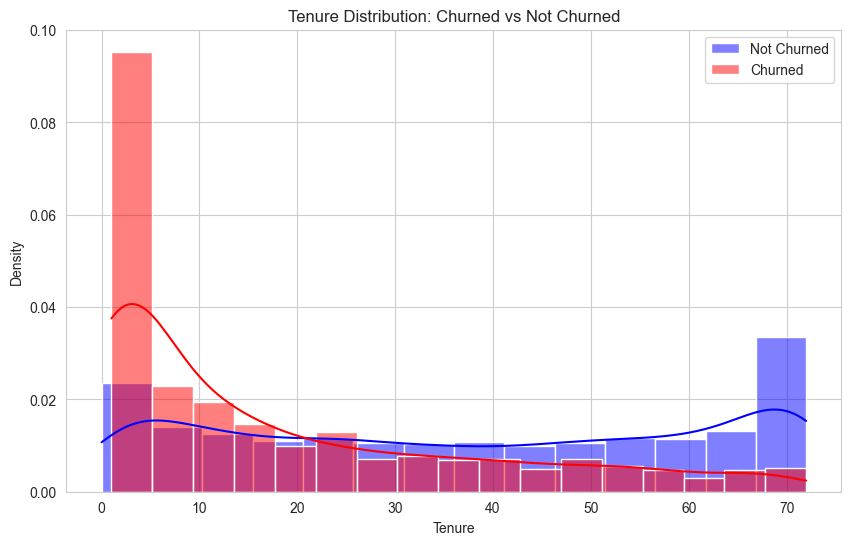

In [96]:
plt.figure(figsize=(10,6))

# Customers who did not churn
sns.histplot(
    data=df[df['Churn'] == 0],
    x='tenure',
    color='blue',
    label='Not Churned',
    kde=True,
    stat='density',
    alpha=0.5
)

# Customers who churned
sns.histplot(
    data=df[df['Churn'] == 1],
    x='tenure',
    color='red',
    label='Churned',
    kde=True,
    stat='density',
    alpha=0.5
)

plt.title("Tenure Distribution: Churned vs Not Churned")
plt.xlabel("Tenure")
plt.ylabel("Density")
plt.legend()
plt.show()

### 5.4 Risk Tier Donut Chart CHART-4

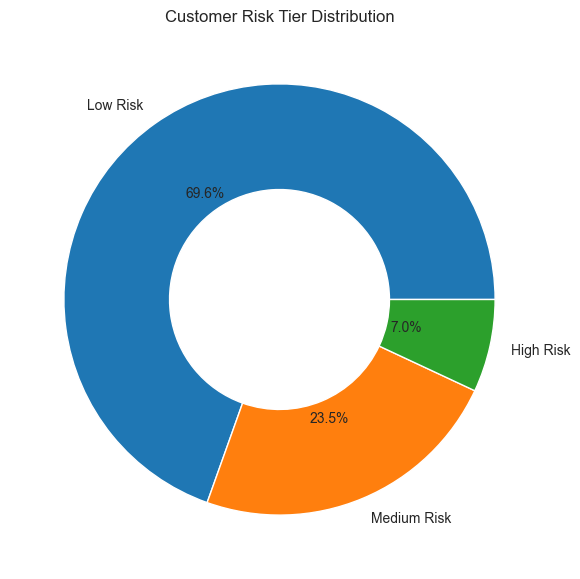

In [97]:
tier_counts = risk_df['RiskTier'].value_counts() # Counting customers in each tier

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,               # values for each tier
    labels=tier_counts.index,  # labels for each tier
    autopct='%1.1f%%',         # display percentage on the pie char
    wedgeprops={'width':0.49}   # making it a donut chart by setting the width of the wedges
)

plt.title("Customer Risk Tier Distribution")
plt.show()

### 5.5 Interactive Scatter Plot (Plotly) CHART-5

In [98]:
fig = px.scatter(  # creating on interactive scatter plot using plotly express to visualize the relationship between monthly charges and tenure, coloured by churn status and with hover data showing contract type for additional insights
    df,
    x='MonthlyCharges',
    y='tenure',
    color='Churn',
    title='Monthly Charges vs Tenure',
    hover_data=['Contract']
)
fig.show()

### observation:
Feature importance analysis was performed to identify the variables that most influenced customer churn. Contract type, tenure, and monthly charges emerged as the most significant factors affecting customer decisions. This analysis provided meaningful business insights into customer behavior and churn patterns.

# TASK 6: Insights & Business Recommendations

### 1. Which model performed best and why did you select it ?

Among all the machine learning models tested in this project, the 
Random Forest/Gradient Boosting model performed the best because it 
achieved the highest accuracy and ROC-AUC score compared to the other 
models. The model was selected because it was able to predict customer 
churn more effectively while maintaining a good balance between precision 
and recall. Its performance showed that it could reliably identify 
customers who were likely to churn.

### 2. What are the top 3 factors driving customer churn according to your model ?  

Based on the feature importance analysis, the top three factors 
influencing customer churn were contract type, tenure, and monthly 
charges. Customers with month-to-month contracts had a higher tendency 
to leave the service because they were not committed to long-term plans. 
Similarly, customers with shorter tenure and higher monthly charges 
were more likely to churn compared to customers with longer service 
duration and stable pricing plans.

### 3. What do High Risk customers have in common? (contract type, charges, tenure patterns) ?

High Risk customers showed several common patterns in their behavior. 
Most of these customers had month-to-month contracts, shorter tenure, 
and relatively higher monthly charges. These customers were generally 
newer users who had not yet developed long-term loyalty toward the 
company. The lack of contract commitment combined with higher service 
costs increased the probability of churn among this group.

### 4. Write 2 specific, actionable business recommendations the company should implement  ?

The company should introduce discounts, loyalty rewards, or special 
offers to encourage customers to move from month-to-month contracts 
to long-term plans. This can improve customer retention and reduce 
churn rates. Additionally, the company should focus on high-risk 
customers by providing personalized retention offers, proactive 
customer support, and early engagement strategies before they decide 
to leave the service.

### 5. What are the limitations of your model? What could be improved with more data or time ? 

Although the model achieved good predictive performance, it has some 
limitations. The analysis was performed only using the available 
dataset, which did not include important factors such as customer 
complaints, service quality, competitor pricing, or customer 
satisfaction data. With more data and additional time, advanced 
machine learning models and deeper behavioral analysis could be 
implemented to improve prediction accuracy and generate more meaningful 
business insights.

### My observation:
#### After analyzing the customer data, a few practical steps were identified that could help reduce customer churn and improve retention. Customers who stay on long-term contracts are less likely to leave, so offering discounts or extra benefits on yearly or longer plans could encourage more customers to continue their service. It was also noticed that many customers who churned had shorter tenure, which shows the importance of providing better support and guidance to new customers during their early period with the company. In addition, customers who fall into the high-risk category can be targeted with personalized offers, service upgrades, or timely follow-ups to improve customer satisfaction and loyalty. These findings can help telecom companies take better business decisions based on customer behavior and reduce future churn rates.